# DeepESN and nonlinear readout benchmark

Goal:

1. Test whether reservoir depth improves over shallow ESN.
2. Test whether a stronger readout improves separability.
3. Keep the first experiment narrow: PCA-6 input only.
4. Aggregate across seeds instead of selecting lucky runs.

Suggested interpretation:

- `DeepESN-linear`: deeper reservoir, simple readout.
- `ESN-MLP`: shallow reservoir, nonlinear readout.
- `DeepESN-MLP`: stronger hybrid benchmark.

This is no longer a pure ESN benchmark once MLP readouts are used; it is a stronger classical reservoir benchmark.

In [1]:
from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir("..")

print(Path.cwd())

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qpitome_qrc.data.loaders import load_market_stress_data
from qpitome_qrc.baselines.esn_benchmark import (
    default_esn_feature_sets,
    build_sequence_splits_for_feature_set,
)
from qpitome_qrc.baselines.deep_esn import (
    DeepESNConfig,
    deep_esn_configs,
    fit_deep_esn,
    summarize_deep_esn_run,
)
from qpitome_qrc.baselines.reservoir_readouts import ReadoutConfig
from qpitome_qrc.evaluation.plots import ensure_dir

## 1. Load data and build PCA-6 sequence splits

PCA-6 was the best ESN input representation in the previous benchmark and is also the likely QRC input representation.

In [3]:
df = load_market_stress_data()
print(df.shape)
df.head()

(7790, 29)


,date,spy_open,spy_high,spy_low,spy_close,spy_adj_close,spy_volume,vix_close,spy_log_return,spy_return,...,vix_ma_5d,future_rv_5d,rv_60d,rv_5d_ewm_5,rv_5d_ewm_20,rv_ratio_5_20,rv_ratio_20_60,rv_excess_5_vs_20,rv_excess_5_vs_60,future_high_vol_label
0,1993-04-27,43.3438,43.8750,43.3438,43.8750,24.8492,156800,13.93,0.010742,0.010800,...,13.466,0.051227,0.120579,0.092666,0.093295,1.178361,0.990142,0.047389,0.020106,0
1,1993-04-28,43.8125,43.9063,43.7188,43.7813,24.7961,85900,13.12,-0.002139,-0.002137,...,13.668,0.029129,0.119761,0.108308,0.097704,1.178972,0.988643,0.041887,0.019830,0
2,1993-04-29,43.8750,43.9688,43.6250,43.9688,24.9023,85000,12.80,0.004274,0.004283,...,13.692,0.057600,0.120012,0.111327,0.099577,0.976333,1.001667,0.017790,-0.002645,0
3,1993-04-30,44.1250,44.2813,44.0313,44.0313,24.9377,88500,12.42,0.001421,0.001422,...,13.504,0.065258,0.118020,0.111095,0.100630,0.919360,1.019599,0.009999,-0.007391,0
4,1993-05-03,44.0938,44.3125,43.9063,44.3125,25.0970,80500,12.90,0.006368,0.006388,...,13.034,0.050154,0.118453,0.099903,0.098429,0.796834,0.821309,-0.020908,-0.040932,0


In [4]:
feature_sets = default_esn_feature_sets(df, pca_components=6, corr_threshold=0.95)
pca6_feature_set = [fs for fs in feature_sets if fs.name == "compact_pca_6"][0]
pca6_feature_set

ESNFeatureSet(name='compact_pca_6', features=['spy_log_return', 'spy_abs_return', 'spy_range', 'spy_dollar_volume', 'rv_5d', 'rv_10d', 'rv_20d', 'spy_drawdown_20d', 'vix_close', 'vix_change', 'vix_pct_change', 'vix_ma_5d'], transformer_builder=<function default_esn_feature_sets.<locals>.<lambda> at 0x163bae840>)

In [5]:
# Start with 20 and 40 day windows, as before.
splits_by_seq_len = {}
feature_names_by_seq_len = {}

for seq_len in (20, 40):
    splits, feature_names = build_sequence_splits_for_feature_set(
        df=df,
        feature_set=pca6_feature_set,
        seq_len=seq_len,
    )
    splits_by_seq_len[seq_len] = splits
    feature_names_by_seq_len[seq_len] = feature_names
    print(seq_len, feature_names)
    for name, (X, y, dates) in splits.items():
        print("  ", name, X.shape, y.shape, dates.min(), dates.max(), "pos_rate", y.mean())

20 ['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5']
   train (5692, 20, 6) (5692,) 1993-05-24T00:00:00.000000 2015-12-31T00:00:00.000000 pos_rate 0.20994378074490513
   val (1006, 20, 6) (1006,) 2016-01-04T00:00:00.000000 2019-12-31T00:00:00.000000 pos_rate 0.1073558648111332
   test (1073, 20, 6) (1073,) 2020-01-02T00:00:00.000000 2024-04-08T00:00:00.000000 pos_rate 0.2488350419384902
40 ['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5']
   train (5672, 40, 6) (5672,) 1993-06-22T00:00:00.000000 2015-12-31T00:00:00.000000 pos_rate 0.21068406205923837
   val (1006, 40, 6) (1006,) 2016-01-04T00:00:00.000000 2019-12-31T00:00:00.000000 pos_rate 0.1073558648111332
   test (1073, 40, 6) (1073,) 2020-01-02T00:00:00.000000 2024-04-08T00:00:00.000000 pos_rate 0.2488350419384902


## 2. Experiment A: depth with linear readouts

This tests depth first, without adding a nonlinear output classifier.

Architectures:

- `(300,)`: shallow ESN
- `(300, 300)`: two-layer DeepESN
- `(600,)`: wider shallow ESN
- `(600, 300)`: wide-then-compressed DeepESN

Readouts:

- logistic
- ridge

Use mean validation PR-AUC across seeds for selection.

In [6]:
depth_configs = deep_esn_configs(
    layer_units=((300,), (300, 300), (600,), (600, 300)),
    spectral_radius=(0.7,),
    leak_rate=(0.5,),
    reservoir_connectivity=(0.1,),
    seeds=(1, 2, 3),
    washout=(0,),
    pooling=("final",),
    state_mode=("last_layer",),
)

linear_readouts = [
    ReadoutConfig(
        kind="logistic",
        scale_states=False,
        class_weight="balanced",
        params={"C": 0.1},
    ),
    ReadoutConfig(
        kind="ridge",
        scale_states=False,
        class_weight="balanced",
        params={"alpha": 1.0},
    ),
]

print("depth configs:", len(depth_configs))
print("readouts:", [r.kind for r in linear_readouts])
print("expected fits:", len(depth_configs) * len(linear_readouts) * len(splits_by_seq_len))

depth configs: 12
readouts: ['logistic', 'ridge']
expected fits: 48


In [7]:
rows = []
results = {}
run_idx = 0

for seq_len, splits in splits_by_seq_len.items():
    for cfg in depth_configs:
        for readout_cfg in linear_readouts:
            run_idx += 1
            print(f"[{run_idx}] seq_len={seq_len} layers={cfg.layer_units} seed={cfg.seed} readout={readout_cfg.kind}")
            result = fit_deep_esn(
                splits=splits,
                config=cfg,
                readout_config=readout_cfg,
                tune_threshold=True,
            )
            row = summarize_deep_esn_run(result)
            row.update({
                "experiment": "depth_linear",
                "seq_len": seq_len,
                "run_idx": run_idx,
            })
            rows.append(row)
            results[run_idx] = result

depth_summary = pd.DataFrame(rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
depth_summary.head(20)

[1] seq_len=20 layers=(300,) seed=1 readout=logistic
[2] seq_len=20 layers=(300,) seed=1 readout=ridge
[3] seq_len=20 layers=(300,) seed=2 readout=logistic
[4] seq_len=20 layers=(300,) seed=2 readout=ridge
[5] seq_len=20 layers=(300,) seed=3 readout=logistic
[6] seq_len=20 layers=(300,) seed=3 readout=ridge
[7] seq_len=20 layers=(300, 300) seed=1 readout=logistic
[8] seq_len=20 layers=(300, 300) seed=1 readout=ridge
[9] seq_len=20 layers=(300, 300) seed=2 readout=logistic
[10] seq_len=20 layers=(300, 300) seed=2 readout=ridge
[11] seq_len=20 layers=(300, 300) seed=3 readout=logistic
[12] seq_len=20 layers=(300, 300) seed=3 readout=ridge
[13] seq_len=20 layers=(600,) seed=1 readout=logistic
[14] seq_len=20 layers=(600,) seed=1 readout=ridge
[15] seq_len=20 layers=(600,) seed=2 readout=logistic
[16] seq_len=20 layers=(600,) seed=2 readout=ridge
[17] seq_len=20 layers=(600,) seed=3 readout=logistic
[18] seq_len=20 layers=(600,) seed=3 readout=ridge
[19] seq_len=20 layers=(600, 300) seed=1

,layer_units,spectral_radius,leak_rate,reservoir_connectivity,input_scaling,input_connectivity,seed,washout,pooling,state_mode,...,val_f1_class_1,test_balanced_accuracy,test_roc_auc,test_pr_auc,test_precision_class_1,test_recall_class_1,test_f1_class_1,experiment,seq_len,run_idx
0,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.579592,0.749617,0.844583,0.660794,0.434944,0.876404,0.581366,depth_linear,20,1
1,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.579592,0.747744,0.844569,0.661410,0.433892,0.872659,0.579602,depth_linear,40,25
2,"(600,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,3,0,final,last_layer,...,0.572864,0.740195,0.834918,0.669549,0.436647,0.838951,0.574359,depth_linear,40,41
3,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.592233,0.699803,0.786210,0.573456,0.393502,0.816479,0.531060,depth_linear,20,2
4,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.592233,0.701055,0.785829,0.570792,0.393885,0.820225,0.532199,depth_linear,40,26
5,"(600,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,3,0,final,last_layer,...,0.569038,0.697612,0.834899,0.669836,0.369301,0.910112,0.525405,depth_linear,20,17
6,"(600,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.582960,0.712326,0.825564,0.661646,0.397213,0.853933,0.542212,depth_linear,40,37
7,"(600,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.582960,0.711085,0.826117,0.662308,0.395833,0.853933,0.540925,depth_linear,20,13
8,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,3,0,final,last_layer,...,0.576132,0.728513,0.831200,0.651817,0.410211,0.872659,0.558084,depth_linear,40,29
9,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,3,0,final,last_layer,...,0.576132,0.732247,0.831772,0.652132,0.413428,0.876404,0.561825,depth_linear,20,5


## 3. Aggregate Experiment A across seeds

In [9]:
def make_hashable_key(x):
    if isinstance(x, dict):
        return str(sorted(x.items()))
    if isinstance(x, list):
        return str(tuple(x))
    return str(x)

for d in [depth_summary]:
    d["layer_units_key"] = d["layer_units"].map(make_hashable_key)
    d["spectral_radius_key"] = d["spectral_radius"].map(make_hashable_key)
    d["leak_rate_key"] = d["leak_rate"].map(make_hashable_key)
    d["reservoir_connectivity_key"] = d["reservoir_connectivity"].map(make_hashable_key)
    d["readout_params_key"] = d["readout_params"].map(make_hashable_key)

group_cols = [
    "experiment",
    "seq_len",
    "layer_units_key",
    "spectral_radius_key",
    "leak_rate_key",
    "reservoir_connectivity_key",
    "pooling",
    "state_mode",
    "readout_kind",
    "readout_scale_states",
    "readout_params_key",
]

depth_agg = (
    depth_summary
    .groupby(group_cols, as_index=False)
    .agg(
        mean_val_pr_auc=("val_pr_auc", "mean"),
        std_val_pr_auc=("val_pr_auc", "std"),
        mean_val_f1=("val_f1_class_1", "mean"),
        mean_val_precision=("val_precision_class_1", "mean"),
        mean_val_recall=("val_recall_class_1", "mean"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        mean_test_f1=("test_f1_class_1", "mean"),
        n_seeds=("val_pr_auc", "size"),
    )
    .sort_values("mean_val_pr_auc", ascending=False)
    .reset_index(drop=True)
)

depth_agg.head(20)

,experiment,seq_len,layer_units_key,spectral_radius_key,leak_rate_key,reservoir_connectivity_key,pooling,state_mode,readout_kind,readout_scale_states,readout_params_key,mean_val_pr_auc,std_val_pr_auc,mean_val_f1,mean_val_precision,mean_val_recall,mean_test_pr_auc,mean_test_f1,n_seeds
0,depth_linear,40,"(600,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,logistic,False,"[('C', 0.1)]",0.539366,0.022999,0.579719,0.573965,0.592593,0.658728,0.550815,3
1,depth_linear,20,"(600,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,logistic,False,"[('C', 0.1)]",0.537138,0.021659,0.578444,0.538201,0.626543,0.658864,0.533721,3
2,depth_linear,20,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,logistic,False,"[('C', 0.1)]",0.535736,0.025435,0.570115,0.514820,0.638889,0.663561,0.571656,3
3,depth_linear,40,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,logistic,False,"[('C', 0.1)]",0.535330,0.024527,0.570115,0.514820,0.638889,0.663698,0.570053,3
4,depth_linear,20,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,ridge,False,"[('alpha', 1.0)]",0.493446,0.061572,0.544763,0.511999,0.629630,0.579544,0.518885,3
5,depth_linear,40,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,ridge,False,"[('alpha', 1.0)]",0.493049,0.061501,0.546816,0.505848,0.632716,0.577938,0.518161,3
6,depth_linear,20,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,logistic,False,"[('C', 0.1)]",0.486826,0.048094,0.530272,0.514968,0.555556,0.593291,0.555731,3
7,depth_linear,40,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,logistic,False,"[('C', 0.1)]",0.486388,0.047378,0.529782,0.520131,0.552469,0.592910,0.554154,3
8,depth_linear,20,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,ridge,False,"[('alpha', 1.0)]",0.454915,0.038410,0.503295,0.467619,0.564815,0.568370,0.543428,3
9,depth_linear,40,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,ridge,False,"[('alpha', 1.0)]",0.454102,0.037147,0.498914,0.470412,0.546296,0.567162,0.547449,3


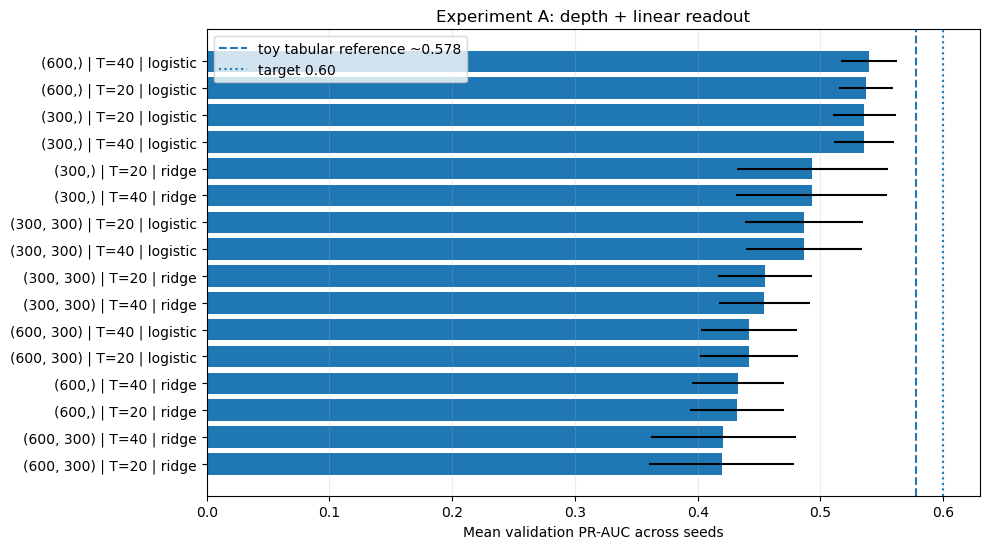

In [11]:
plot_df = depth_agg.sort_values("mean_val_pr_auc", ascending=True).tail(20)

labels = (
    plot_df["layer_units_key"]
    + " | T=" + plot_df["seq_len"].astype(str)
    + " | " + plot_df["readout_kind"]
)

plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
plt.barh(
    labels,
    plot_df["mean_val_pr_auc"],
    xerr=plot_df["std_val_pr_auc"].fillna(0),
)
plt.axvline(0.578, linestyle="--", label="toy tabular reference ~0.578")
plt.axvline(0.600, linestyle=":", label="target 0.60")
plt.xlabel("Mean validation PR-AUC across seeds")
plt.title("Experiment A: depth + linear readout")
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Experiment B: small reservoir + nonlinear readout

This tests whether the reservoir state contains useful nonlinear structure that a linear readout fails to separate.

Keep this small first. MLP readouts can overfit.

In [12]:
mlp_reservoir_configs = deep_esn_configs(
    layer_units=((300,), (300, 300)),
    spectral_radius=(0.7,),
    leak_rate=(0.5,),
    reservoir_connectivity=(0.1,),
    seeds=(1, 2, 3),
    washout=(0,),
    pooling=("final",),
    state_mode=("last_layer",),
)

mlp_readouts = [
    ReadoutConfig(
        kind="mlp",
        scale_states=True,
        class_weight=None,
        params={
            "hidden_layer_sizes": (16,),
            "activation": "relu",
            "alpha": 1e-3,
            "learning_rate_init": 1e-3,
            "max_iter": 500,
            "early_stopping": True,
        },
    ),
    ReadoutConfig(
        kind="mlp",
        scale_states=True,
        class_weight=None,
        params={
            "hidden_layer_sizes": (32,),
            "activation": "relu",
            "alpha": 1e-3,
            "learning_rate_init": 1e-3,
            "max_iter": 500,
            "early_stopping": True,
        },
    ),
]

print("reservoir configs:", len(mlp_reservoir_configs))
print("readout configs:", len(mlp_readouts))
print("expected fits:", len(mlp_reservoir_configs) * len(mlp_readouts) * len(splits_by_seq_len))

reservoir configs: 6
readout configs: 2
expected fits: 24


In [13]:
mlp_rows = []
mlp_results = {}
mlp_run_idx = 0

for seq_len, splits in splits_by_seq_len.items():
    for cfg in mlp_reservoir_configs:
        for readout_cfg in mlp_readouts:
            mlp_run_idx += 1
            print(f"[{mlp_run_idx}] seq_len={seq_len} layers={cfg.layer_units} seed={cfg.seed} readout={readout_cfg.params}")
            result = fit_deep_esn(
                splits=splits,
                config=cfg,
                readout_config=readout_cfg,
                tune_threshold=True,
            )
            row = summarize_deep_esn_run(result)
            row.update({
                "experiment": "mlp_readout",
                "seq_len": seq_len,
                "run_idx": mlp_run_idx,
            })
            mlp_rows.append(row)
            mlp_results[mlp_run_idx] = result

mlp_summary = pd.DataFrame(mlp_rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
mlp_summary.head(20)

[1] seq_len=20 layers=(300,) seed=1 readout={'hidden_layer_sizes': (16,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 500, 'early_stopping': True}
[2] seq_len=20 layers=(300,) seed=1 readout={'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 500, 'early_stopping': True}
[3] seq_len=20 layers=(300,) seed=2 readout={'hidden_layer_sizes': (16,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 500, 'early_stopping': True}
[4] seq_len=20 layers=(300,) seed=2 readout={'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 500, 'early_stopping': True}
[5] seq_len=20 layers=(300,) seed=3 readout={'hidden_layer_sizes': (16,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 500, 'early_stopping': True}
[6] seq_len=20 layers=(300,) seed=3 readout={'hidden_layer_sizes': (32,), 'activation': 'r

,layer_units,spectral_radius,leak_rate,reservoir_connectivity,input_scaling,input_connectivity,seed,washout,pooling,state_mode,...,val_f1_class_1,test_balanced_accuracy,test_roc_auc,test_pr_auc,test_precision_class_1,test_recall_class_1,test_f1_class_1,experiment,seq_len,run_idx
0,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,1,0,final,last_layer,...,0.544554,0.761803,0.832604,0.662321,0.486425,0.805243,0.606488,mlp_readout,40,19
1,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,3,0,final,last_layer,...,0.556701,0.709670,0.799621,0.641304,0.411197,0.797753,0.542675,mlp_readout,40,24
2,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,3,0,final,last_layer,...,0.544601,0.653509,0.805917,0.631269,0.335684,0.891386,0.487705,mlp_readout,20,12
3,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.542510,0.740862,0.841990,0.629372,0.431818,0.853933,0.573585,mlp_readout,40,13
4,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,1,0,final,last_layer,...,0.547945,0.771038,0.845805,0.646910,0.518610,0.782772,0.623881,mlp_readout,20,1
5,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,3,0,final,last_layer,...,0.585366,0.706111,0.809635,0.639012,0.391379,0.850187,0.536009,mlp_readout,40,23
6,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,3,0,final,last_layer,...,0.562162,0.739998,0.810917,0.648258,0.465169,0.775281,0.581461,mlp_readout,20,11
7,"(300,)","(0.7,)","(0.5,)","(0.1,)",0.5,0.5,2,0,final,last_layer,...,0.548523,0.782449,0.867534,0.706737,0.490405,0.861423,0.625000,mlp_readout,40,15
8,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,1,0,final,last_layer,...,0.517544,0.743413,0.820578,0.634609,0.427007,0.876404,0.574233,mlp_readout,20,7
9,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",0.5,0.5,1,0,final,last_layer,...,0.518135,0.738653,0.824263,0.600479,0.481752,0.741573,0.584071,mlp_readout,20,8


## 5. Aggregate Experiment B

In [14]:
def make_hashable_key(x):
    if isinstance(x, dict):
        return str(sorted(x.items()))
    if isinstance(x, list):
        return str(tuple(x))
    return str(x)

for d in [mlp_summary]:
    d["layer_units_key"] = d["layer_units"].map(make_hashable_key)
    d["spectral_radius_key"] = d["spectral_radius"].map(make_hashable_key)
    d["leak_rate_key"] = d["leak_rate"].map(make_hashable_key)
    d["reservoir_connectivity_key"] = d["reservoir_connectivity"].map(make_hashable_key)
    d["readout_params_key"] = d["readout_params"].map(make_hashable_key)

group_cols = [
    "experiment",
    "seq_len",
    "layer_units_key",
    "spectral_radius_key",
    "leak_rate_key",
    "reservoir_connectivity_key",
    "pooling",
    "state_mode",
    "readout_kind",
    "readout_scale_states",
    "readout_params_key",
]

mlp_agg = (
    mlp_summary
    .groupby(group_cols, as_index=False)
    .agg(
        mean_val_pr_auc=("val_pr_auc", "mean"),
        std_val_pr_auc=("val_pr_auc", "std"),
        mean_val_f1=("val_f1_class_1", "mean"),
        mean_val_precision=("val_precision_class_1", "mean"),
        mean_val_recall=("val_recall_class_1", "mean"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        mean_test_f1=("test_f1_class_1", "mean"),
        n_seeds=("val_pr_auc", "size"),
    )
    .sort_values("mean_val_pr_auc", ascending=False)
    .reset_index(drop=True)
)

mlp_agg.head(20)

,experiment,seq_len,layer_units_key,spectral_radius_key,leak_rate_key,reservoir_connectivity_key,pooling,state_mode,readout_kind,readout_scale_states,readout_params_key,mean_val_pr_auc,std_val_pr_auc,mean_val_f1,mean_val_precision,mean_val_recall,mean_test_pr_auc,mean_test_f1,n_seeds
0,mlp_readout,40,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.542771,0.028377,0.541293,0.475216,0.632716,0.673650,0.593317,3
1,mlp_readout,20,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.536306,0.019122,0.534986,0.526563,0.583333,0.649924,0.548904,3
2,mlp_readout,20,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.528874,0.026622,0.537830,0.534663,0.558642,0.676141,0.615796,3
3,mlp_readout,40,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.528653,0.037459,0.541657,0.505751,0.617284,0.660479,0.513560,3
4,mlp_readout,40,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.527660,0.068796,0.543307,0.550731,0.543210,0.659974,0.560840,3
5,mlp_readout,20,"(300, 300)","(0.7, 0.7)","(0.5, 0.5)","(0.1, 0.1)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.527253,0.044031,0.532723,0.535457,0.543210,0.629312,0.525849,3
6,mlp_readout,20,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.517086,0.009585,0.542525,0.477683,0.641975,0.680247,0.573130,3
7,mlp_readout,40,"(300,)","(0.7,)","(0.5,)","(0.1,)",final,last_layer,mlp,True,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.511508,0.012371,0.534285,0.447441,0.666667,0.679742,0.595052,3


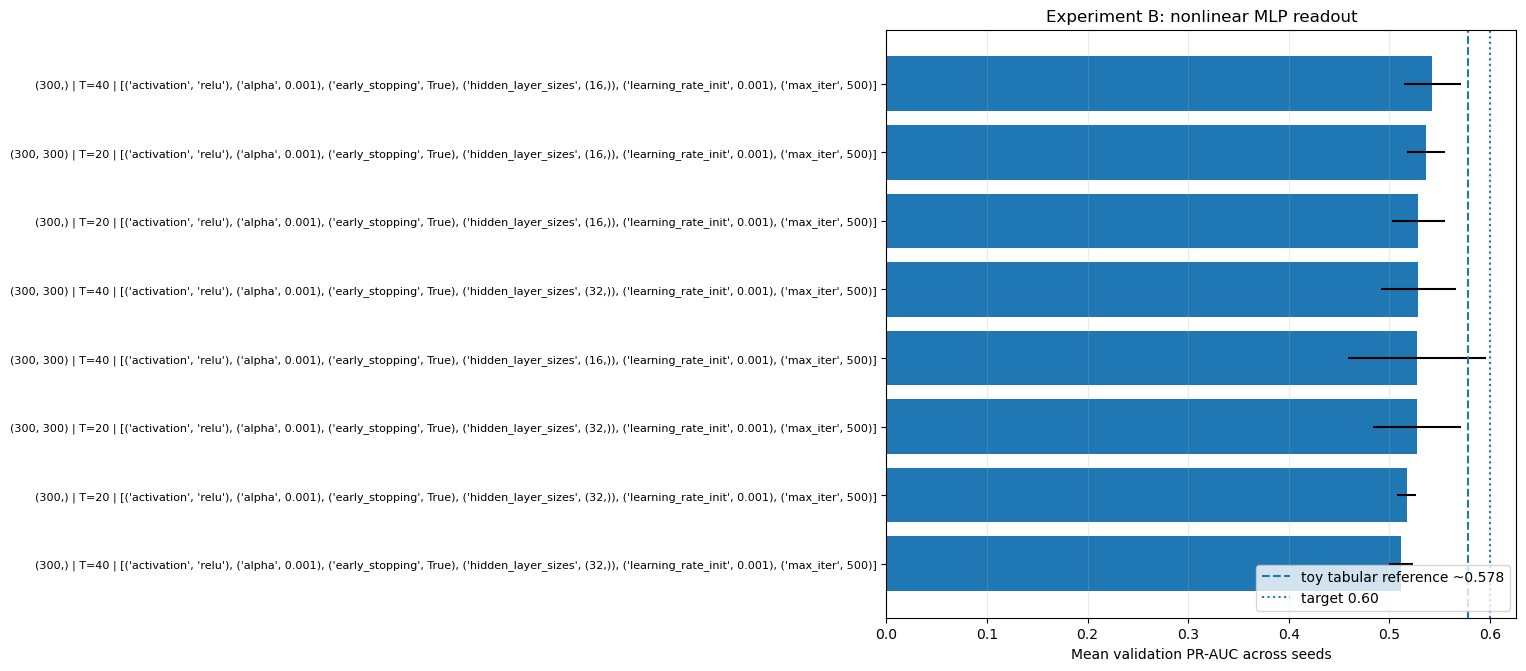

In [22]:
plot_df = mlp_agg.sort_values("mean_val_pr_auc", ascending=True).tail(20).copy()

labels = (
    plot_df["layer_units_key"]
    + " | T=" + plot_df["seq_len"].astype(str)
    + " | " + plot_df["readout_params_key"]
)

fig_height = max(7, 0.55 * len(plot_df))

fig, ax = plt.subplots(figsize=(15, fig_height))

ax.barh(
    labels,
    plot_df["mean_val_pr_auc"],
    xerr=plot_df["std_val_pr_auc"].fillna(0),
)

ax.axvline(0.578, linestyle="--", label="toy tabular reference ~0.578")
ax.axvline(0.600, linestyle=":", label="target 0.60")

ax.set_xlabel("Mean validation PR-AUC across seeds")
ax.set_title("Experiment B: nonlinear MLP readout")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")

ax.tick_params(axis="y", labelsize=8)

plt.subplots_adjust(left=0.55, right=0.97, top=0.92, bottom=0.08)
plt.show()

## 6. Combined comparison

In [24]:
combined_agg = pd.concat([depth_agg, mlp_agg], ignore_index=True)
combined_agg = combined_agg.sort_values("mean_val_pr_auc", ascending=False).reset_index(drop=True)

display_cols = [
    "experiment",
    "seq_len",
    "layer_units_key",
    "readout_kind",
    "readout_params_key",
    "mean_val_pr_auc",
    "std_val_pr_auc",
    "mean_val_f1",
    "mean_val_precision",
    "mean_val_recall",
    "mean_test_pr_auc",
    "mean_test_f1",
    "n_seeds",
]

combined_agg[display_cols].head(30)

,experiment,seq_len,layer_units_key,readout_kind,readout_params_key,mean_val_pr_auc,std_val_pr_auc,mean_val_f1,mean_val_precision,mean_val_recall,mean_test_pr_auc,mean_test_f1,n_seeds
0,mlp_readout,40,"(300,)",mlp,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.542771,0.028377,0.541293,0.475216,0.632716,0.673650,0.593317,3
1,depth_linear,40,"(600,)",logistic,"[('C', 0.1)]",0.539366,0.022999,0.579719,0.573965,0.592593,0.658728,0.550815,3
2,depth_linear,20,"(600,)",logistic,"[('C', 0.1)]",0.537138,0.021659,0.578444,0.538201,0.626543,0.658864,0.533721,3
3,mlp_readout,20,"(300, 300)",mlp,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.536306,0.019122,0.534986,0.526563,0.583333,0.649924,0.548904,3
4,depth_linear,20,"(300,)",logistic,"[('C', 0.1)]",0.535736,0.025435,0.570115,0.514820,0.638889,0.663561,0.571656,3
5,depth_linear,40,"(300,)",logistic,"[('C', 0.1)]",0.535330,0.024527,0.570115,0.514820,0.638889,0.663698,0.570053,3
6,mlp_readout,20,"(300,)",mlp,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.528874,0.026622,0.537830,0.534663,0.558642,0.676141,0.615796,3
7,mlp_readout,40,"(300, 300)",mlp,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.528653,0.037459,0.541657,0.505751,0.617284,0.660479,0.513560,3
8,mlp_readout,40,"(300, 300)",mlp,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.527660,0.068796,0.543307,0.550731,0.543210,0.659974,0.560840,3
9,mlp_readout,20,"(300, 300)",mlp,"[('activation', 'relu'), ('alpha', 0.001), ('e...",0.527253,0.044031,0.532723,0.535457,0.543210,0.629312,0.525849,3


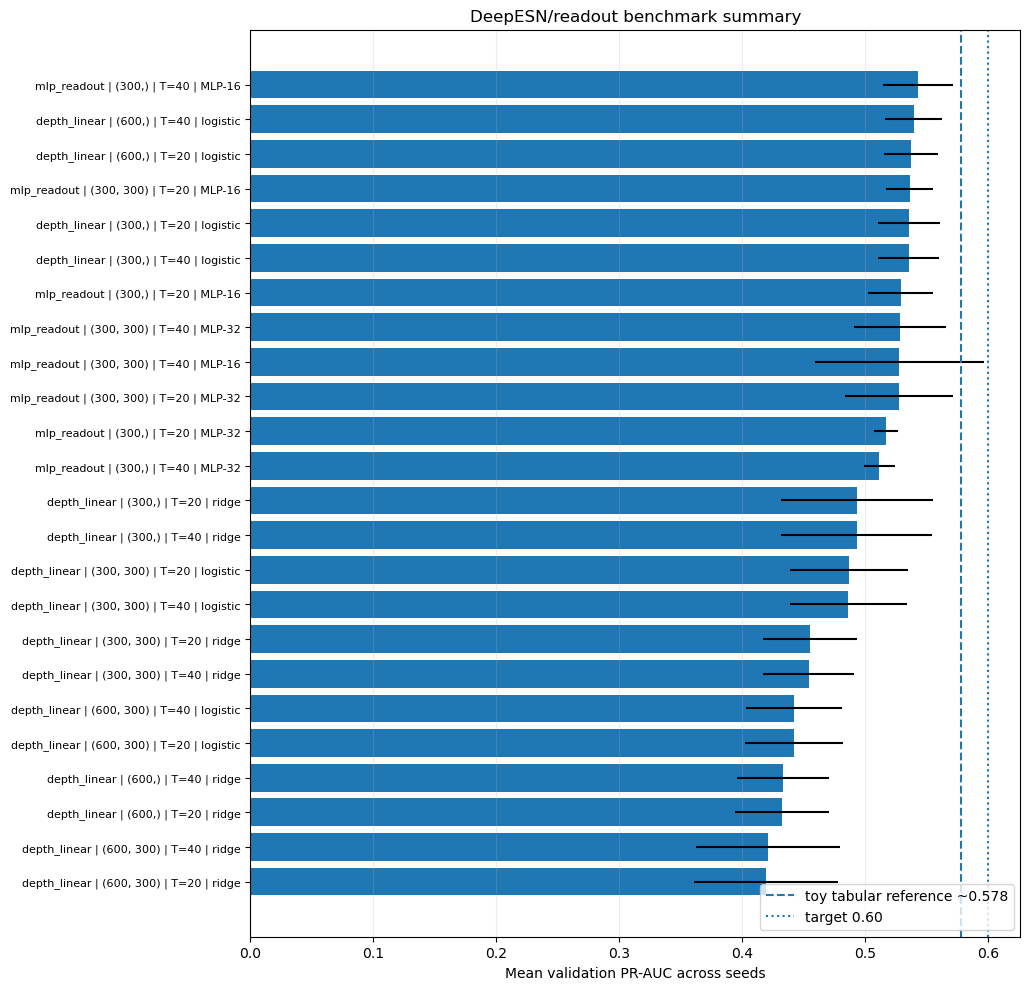

In [25]:
plot_df = combined_agg.sort_values("mean_val_pr_auc", ascending=True).tail(25).copy()

def short_readout_label(row):
    if row["readout_kind"] in ["logistic", "ridge"]:
        return row["readout_kind"]
    if row["readout_kind"] == "mlp":
        params = row["readout_params_key"]
        if "hidden_layer_sizes', (16,)" in params:
            return "MLP-16"
        if "hidden_layer_sizes', (32,)" in params:
            return "MLP-32"
        return "MLP"
    return row["readout_kind"]

plot_df["readout_short"] = plot_df.apply(short_readout_label, axis=1)

labels = (
    plot_df["experiment"]
    + " | "
    + plot_df["layer_units_key"]
    + " | T="
    + plot_df["seq_len"].astype(str)
    + " | "
    + plot_df["readout_short"]
)

fig_height = max(7, 0.45 * len(plot_df))
fig, ax = plt.subplots(figsize=(14, fig_height))

ax.barh(
    labels,
    plot_df["mean_val_pr_auc"],
    xerr=plot_df["std_val_pr_auc"].fillna(0),
)

ax.axvline(0.578, linestyle="--", label="toy tabular reference ~0.578")
ax.axvline(0.600, linestyle=":", label="target 0.60")

ax.set_xlabel("Mean validation PR-AUC across seeds")
ax.set_title("DeepESN/readout benchmark summary")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
ax.tick_params(axis="y", labelsize=8)

plt.subplots_adjust(left=0.42, right=0.97, top=0.92, bottom=0.08)
plt.show()

## 7. Save outputs

In [ ]:
OUT_DIR = Path("reports/deep_esn_benchmark/tables")
ensure_dir(OUT_DIR)

depth_summary.to_csv(OUT_DIR / "depth_linear_runs.csv", index=False)
depth_agg.to_csv(OUT_DIR / "depth_linear_seed_aggregate.csv", index=False)
mlp_summary.to_csv(OUT_DIR / "mlp_readout_runs.csv", index=False)
mlp_agg.to_csv(OUT_DIR / "mlp_readout_seed_aggregate.csv", index=False)
combined_agg.to_csv(OUT_DIR / "combined_seed_aggregate.csv", index=False)

print(OUT_DIR)

## 8. Interpretation scratchpad

Questions:

1. Does two-layer DeepESN beat shallow ESN?
2. Does ridge readout beat logistic?
3. Does MLP readout improve validation PR-AUC or just overfit?
4. Does precision improve, or is recall still carrying the result?
5. Does any configuration beat the toy tabular reference (~0.578 val PR-AUC)?
6. Does anything reach the target ~0.60 val PR-AUC?

If nothing beats the toy tabular reference, the next honest move is HMM/regime modeling or target redesign, not more reservoir tuning.

In [26]:
from qpitome_qrc.baselines.esn import ESNConfig, fit_single_esn

splits20 = splits_by_seq_len[20]

configs = [
    ("300_C0.1", ESNConfig(
        units=300,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("600_C0.1", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("1000_C0.1", ESNConfig(
        units=1000,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("600_C0.01", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.01,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("600_C1.0", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=1.0,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("300_C0.1_scale_states", ESNConfig(
        units=300,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=True,
    )),
]

rows = []
single_results = {}

for name, cfg in configs:
    print("running", name)
    res = fit_single_esn(
        splits=splits20,
        config=cfg,
        tune_threshold=True,
    )
    single_results[name] = res

    rows.append({
        "name": name,
        "units": cfg.units,
        "readout_C": cfg.readout_C,
        "scale_states": cfg.scale_states,
        "threshold": res.threshold,
        "val_pr_auc": res.val_metrics.pr_auc,
        "val_f1": res.val_metrics.f1_class_1,
        "val_precision": res.val_metrics.precision_class_1,
        "val_recall": res.val_metrics.recall_class_1,
        "test_pr_auc": res.test_metrics.pr_auc,
        "test_f1": res.test_metrics.f1_class_1,
        "test_precision": res.test_metrics.precision_class_1,
        "test_recall": res.test_metrics.recall_class_1,
    })

local_scan = pd.DataFrame(rows).sort_values("val_pr_auc", ascending=False)
local_scan

running 300_C0.1
running 600_C0.1
running 1000_C0.1
running 600_C0.01
running 600_C1.0
running 300_C0.1_scale_states


,name,units,readout_C,scale_states,threshold,val_pr_auc,val_f1,val_precision,val_recall,test_pr_auc,test_f1,test_precision,test_recall
0,300_C0.1,300,0.10,False,0.45,0.561852,0.579592,0.518248,0.657407,0.660794,0.581047,0.435514,0.872659
5,300_C0.1_scale_states,300,0.10,True,0.52,0.556450,0.595349,0.598131,0.592593,0.654372,0.563659,0.420664,0.853933
1,600_C0.1,600,0.10,False,0.51,0.547472,0.582960,0.565217,0.601852,0.662308,0.540094,0.394148,0.857678
3,600_C0.01,600,0.01,False,0.36,0.535848,0.552448,0.443820,0.731481,0.672430,0.537118,0.379045,0.921348
2,1000_C0.1,1000,0.10,False,0.41,0.533350,0.568093,0.489933,0.675926,0.655830,0.523810,0.368341,0.906367
4,600_C1.0,600,1.00,False,0.48,0.525848,0.535088,0.508333,0.564815,0.576874,0.518182,0.371941,0.853933


In [30]:
from qpitome_qrc.baselines.esn import ESNConfig, fit_single_esn

splits20 = splits_by_seq_len[20]

configs = [
    ("300_C0.1", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.5,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("300_C0.2", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.1,
        input_scaling=0.6,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("300_C0.3", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.1,
        input_scaling=0.6,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("300_C0.4", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.1,
        input_scaling=0.7,
        input_connectivity=0.5,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("300_C0.5", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.1,
        input_scaling=0.5,
        input_connectivity=0.5,
        reservoir_connectivity=0.01,
        readout_C=0.1,
        seed=1,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
    ("300_C0.6", ESNConfig(
        units=600,
        spectral_radius=0.7,
        leak_rate=0.1,
        input_scaling=0.6,
        input_connectivity=0.3,
        reservoir_connectivity=0.1,
        readout_C=0.1,
        seed=5,
        washout=0,
        pooling="final",
        scale_states=False,
    )),
]

rows = []
single_results = {}

for name, cfg in configs:
    print("running", name)
    res = fit_single_esn(
        splits=splits20,
        config=cfg,
        tune_threshold=True,
    )
    single_results[name] = res

    rows.append({
        "name": name,
        "units": cfg.units,
        "readout_C": cfg.readout_C,
        "scale_states": cfg.scale_states,
        "threshold": res.threshold,
        "val_pr_auc": res.val_metrics.pr_auc,
        "val_f1": res.val_metrics.f1_class_1,
        "val_precision": res.val_metrics.precision_class_1,
        "val_recall": res.val_metrics.recall_class_1,
        "test_pr_auc": res.test_metrics.pr_auc,
        "test_f1": res.test_metrics.f1_class_1,
        "test_precision": res.test_metrics.precision_class_1,
        "test_recall": res.test_metrics.recall_class_1,
    })

local_scan = pd.DataFrame(rows).sort_values("val_pr_auc", ascending=False)
local_scan

running 300_C0.1
running 300_C0.2
running 300_C0.3
running 300_C0.4
running 300_C0.5
running 300_C0.6


,name,units,readout_C,scale_states,threshold,val_pr_auc,val_f1,val_precision,val_recall,test_pr_auc,test_f1,test_precision,test_recall
3,300_C0.4,600,0.1,False,0.42,0.616272,0.594378,0.524823,0.685185,0.636068,0.452514,0.301115,0.910112
1,300_C0.2,600,0.1,False,0.41,0.610703,0.603175,0.527778,0.703704,0.653982,0.462715,0.310655,0.906367
2,300_C0.3,600,0.1,False,0.41,0.610703,0.603175,0.527778,0.703704,0.653982,0.462715,0.310655,0.906367
5,300_C0.6,600,0.1,False,0.35,0.591784,0.580420,0.466292,0.768519,0.664322,0.463392,0.307882,0.936330
4,300_C0.5,600,0.1,False,0.35,0.586436,0.588652,0.477011,0.768519,0.681819,0.461101,0.308767,0.910112
0,300_C0.1,600,0.1,False,0.51,0.547472,0.582960,0.565217,0.601852,0.662308,0.540094,0.394148,0.857678
